# Seeded LC vs BCO on Mumford0

This notebook mirrors `evaluation.ipynb`, but focuses on a seeded-construction scenario:

1. Run a baseline LC pass on `Mumford0`.
2. Reuse those routes as a non-empty base network for a second LC pass with `n_routes + 1` and `max_route_len + 3`.
3. Run BCO from the same seeded LC network and compare the metrics.


## 1. Imports

In [47]:
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from hydra import compose, initialize_config_dir
from omegaconf import OmegaConf
from torch_geometric.loader import DataLoader

from connectpt.routes_generator.citygraph_dataset import get_dataset_from_config
from connectpt.routes_generator.utils import get_eval_cfg
from connectpt.routes_generator.eval_route_generator import eval_model
from connectpt.routes_generator.bee_colony import bee_colony
from connectpt.routes_generator.torch_utils import dump_routes, get_batch_tensor_from_routes
import connectpt.routes_generator.utils as lrnu


## 2. Paths And Experiment Parameters

In [48]:
def find_repo_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / "connectpt").exists() and (candidate / "examples").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root from current working directory")

ROOT_DIR = find_repo_root()
CFG_DIR = ROOT_DIR / "connectpt" / "routes_generator" / "cfg"
BENCHMARK_DIR = ROOT_DIR / "examples" / "data" / "benchmark"
MODEL_WEIGHTS_PATH = ROOT_DIR / "examples" / "data" / "model_weights" / "inductive_random_graphs_weighted_connectivity.pt"
OUTPUT_ROUTES_DIR = ROOT_DIR / "examples" / "route_generator" / "output_routes"

CITY_NAME = "Mumford0"

BASE_N_ROUTES = 3
BASE_MIN_ROUTE_LEN = 2
BASE_MAX_ROUTE_LEN = 5

SEEDED_N_ROUTES = BASE_N_ROUTES +1
SEEDED_MIN_ROUTE_LEN = BASE_MIN_ROUTE_LEN
SEEDED_MAX_ROUTE_LEN = BASE_MAX_ROUTE_LEN + 3

LC_SAMPLES = 100
USE_NEURAL_BCO = False
BCO_N_BEES = 10
BCO_N_ITERATIONS = 20
BCO_N_TYPE1_BEES = 5

DEMAND_TIME_WEIGHT = 0.33
ROUTE_TIME_WEIGHT = 0.33
MEDIAN_CONNECTIVITY_WEIGHT = 0.33

print(f"ROOT_DIR: {ROOT_DIR}")
print(f"CFG_DIR: {CFG_DIR}")
print(f"MODEL_WEIGHTS_PATH exists: {MODEL_WEIGHTS_PATH.exists()}")


ROOT_DIR: D:\PythonProjects\connectpt
CFG_DIR: D:\PythonProjects\connectpt\connectpt\routes_generator\cfg
MODEL_WEIGHTS_PATH exists: True


## 3. Load Benchmark Tensors

In [49]:
def load_benchmark_tensors(city_name: str = CITY_NAME) -> dict:
    node_locs = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}Coords.txt", skip_header=1),
        dtype=torch.float32,
    )
    street_adj = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}TravelTimes.txt"),
        dtype=torch.float32,
    ) * 60
    demand = torch.tensor(
        np.genfromtxt(BENCHMARK_DIR / f"{city_name}Demand.txt"),
        dtype=torch.float32,
    )
    return {
        "node_locs": node_locs,
        "street_adj": street_adj,
        "demand": demand,
    }

input_tensors = load_benchmark_tensors()
print({key: tuple(value.shape) for key, value in input_tensors.items()})


{'node_locs': (30, 2), 'street_adj': (30, 30), 'demand': (30, 30)}


## 4. Helper Functions

In [50]:
def make_test_dataloader(dataset_cfg):
    dataset = get_dataset_from_config(dataset_cfg, tensors=input_tensors)
    return DataLoader(dataset, batch_size=1)

def build_lc_cfg(run_name: str, n_routes: int, min_route_len: int, max_route_len: int):
    params = {
        "dataset_name": "tensor",
        "n_routes": n_routes,
        "min_route_len": min_route_len,
        "max_route_len": max_route_len,
        "demand_time_weight": DEMAND_TIME_WEIGHT,
        "route_time_weight": ROUTE_TIME_WEIGHT,
        "median_connectivity_weight": MEDIAN_CONNECTIVITY_WEIGHT,
        "run_name": run_name,
        "model_weights": str(MODEL_WEIGHTS_PATH),
    }
    cfg = get_eval_cfg(str(CFG_DIR), "eval_model_mumford", params)
    cfg.batch_size = 1
    return cfg

def build_bco_cfg(run_name: str, n_routes: int, min_route_len: int, max_route_len: int, use_neural_bees: bool = USE_NEURAL_BCO):
    base_cfg_name = "neural_bco_mumford" if use_neural_bees else "bco_mumford"
    overrides = [
        "+eval=mumford0",
        "++eval.dataset.type=tensor",
        f"++eval.n_routes={n_routes}",
        f"++eval.min_route_len={min_route_len}",
        f"++eval.max_route_len={max_route_len}",
        f"++experiment.cost_function.kwargs.demand_time_weight={DEMAND_TIME_WEIGHT}",
        f"++experiment.cost_function.kwargs.route_time_weight={ROUTE_TIME_WEIGHT}",
        f"++experiment.cost_function.kwargs.median_connectivity_weight={MEDIAN_CONNECTIVITY_WEIGHT}",
        f"++run_name={run_name}",
        f"++n_bees={BCO_N_BEES}",
        f"++n_iterations={BCO_N_ITERATIONS}",
        f"++n_type1_bees={BCO_N_TYPE1_BEES}",
    ]
    if use_neural_bees:
        overrides.append(f"+model.weights={MODEL_WEIGHTS_PATH}")
    with initialize_config_dir(config_dir=str(CFG_DIR), version_base=None):
        cfg = compose(config_name=base_cfg_name, overrides=overrides)
    cfg.batch_size = 1
    return cfg

def run_lc(cfg, init_routes=None):
    dataloader = make_test_dataloader(cfg.eval.dataset)
    device, run_name, _, cost_obj, model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix="lc_",
        weights_required=True,
    )
    init_cfg = OmegaConf.create({"method": "tensor"}) if init_routes is not None else None
    _, unserved_demand, metrics, routes = eval_model(
        model,
        dataloader,
        cfg.eval,
        cost_obj,
        n_samples=LC_SAMPLES,
        return_routes=True,
        silent=True,
        device=device,
        init_cfg=init_cfg,
        routes_tensor=init_routes,
    )
    return run_name, metrics, unserved_demand, routes

def run_bco(cfg, init_routes):
    dataloader = make_test_dataloader(cfg.eval.dataset)
    use_neural_bees = cfg.get("neural_bees", False)
    prefix = "neural_bco_" if use_neural_bees else "bco_"
    device, run_name, _, cost_obj, bee_model = lrnu.process_standard_experiment_cfg(
        cfg,
        run_name_prefix=prefix,
        weights_required=use_neural_bees,
    )
    force_linking_unlinked = cfg.get("force_linking_unlinked", False)
    if not use_neural_bees:
        bee_model = None
    elif bee_model is not None:
        bee_model.force_linking_unlinked = force_linking_unlinked
        bee_model.eval()

    output = lrnu.test_method(
        bee_colony,
        dataloader,
        cfg.eval,
        OmegaConf.create({"method": "tensor"}),
        cost_obj,
        silent=True,
        device=device,
        return_routes=True,
        routes_tensor=init_routes,
        n_bees=cfg.n_bees,
        n_iterations=cfg.n_iterations,
        n_type1_bees=cfg.get("n_type1_bees", None),
        n_type2_bees=cfg.get("n_type2_bees", None),
        bee_model=bee_model,
        force_linking_unlinked=force_linking_unlinked,
        adjustment_degree_weight=cfg.get("adjustment_degree_weight", 0.0),
        adjustment_degree_gap=cfg.get("adjustment_degree_gap", 0.1),
        adjustment_degree_mode=cfg.get("adjustment_degree_mode", "current"),
        adjustment_degree_objective=cfg.get("adjustment_degree_objective", "raw"),
        adjustment_degree_target=cfg.get("adjustment_degree_target", 0.2),
    )
    _, _, unserved_demand, metrics, routes = output
    return run_name, metrics, unserved_demand, routes

def summarize_run(label: str, metrics: dict, routes: torch.Tensor):
    n_nonempty_routes = int(((routes > -1).sum(dim=-1) > 1).sum().item())
    return {
        "method": label,
        "cost": float(metrics["cost"].item()),
        "ATT": float(metrics["ATT"].item()),
        "RTT": float(metrics["RTT"].item()),
        "$d_{un}$": float(metrics["$d_{un}$"].item()),
        "# routes": n_nonempty_routes,
    }


## 5. Baseline LC On Mumford0

In [51]:
cfg_lc_base = build_lc_cfg(
    run_name="seeded_lc_base_mumford0",
    n_routes=BASE_N_ROUTES,
    min_route_len=BASE_MIN_ROUTE_LEN,
    max_route_len=BASE_MAX_ROUTE_LEN,
)

lc_base_run_name, lc_base_metrics, lc_base_unserved, lc_base_routes = run_lc(cfg_lc_base)
dump_routes(lc_base_run_name, lc_base_routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

print(f"Run name: {lc_base_run_name}")
print(f"Cost: {lc_base_metrics['cost'].item():.4f}")
print(f"ATT: {lc_base_metrics['ATT'].item():.4f}")
print(f"RTT: {lc_base_metrics['RTT'].item():.4f}")
print(f"Routes shape: {tuple(lc_base_routes.shape)}")
lc_base_routes


Run name: lc_seeded_lc_base_mumford0
Cost: 5.6502
ATT: 17.3157
RTT: 94.0000
Routes shape: (1, 3, 5)


tensor([[[27, 16, 28, 17, 19],
         [ 0, 17, 11, 14, 23],
         [18,  0, 25,  7, 20]]])

## 6. Seeded LC With One More Route And Larger Max Route Length

In [52]:
cfg_lc_seeded = build_lc_cfg(
    run_name="seeded_lc_second_pass_mumford0",
    n_routes=SEEDED_N_ROUTES,
    min_route_len=SEEDED_MIN_ROUTE_LEN,
    max_route_len=SEEDED_MAX_ROUTE_LEN,
)

lc_seeded_run_name, lc_seeded_metrics, lc_seeded_unserved, lc_seeded_routes = run_lc(
    cfg_lc_seeded,
    init_routes=lc_base_routes,
)
dump_routes(lc_seeded_run_name, lc_seeded_routes.cpu(), out_dir=OUTPUT_ROUTES_DIR)

print(f"Run name: {lc_seeded_run_name}")
print(f"Cost: {lc_seeded_metrics['cost'].item():.4f}")
print(f"ATT: {lc_seeded_metrics['ATT'].item():.4f}")
print(f"RTT: {lc_seeded_metrics['RTT'].item():.4f}")
print(f"Routes shape: {tuple(lc_seeded_routes.shape)}")
lc_seeded_routes


Run name: lc_seeded_lc_second_pass_mumford0
Cost: 4.7947
ATT: 20.0115
RTT: 142.0000
Routes shape: (1, 4, 6)


tensor([[[27, 16, 28, 17, 19, -1],
         [ 0, 17, 11, 14, 23, -1],
         [18,  0, 25,  7, 20, -1],
         [10,  6, 13,  0, 12,  8]]])

## 7. Seeded BCO From The Same LC Initialization

In [53]:
cfg_bco_seeded = build_bco_cfg(
    run_name="seeded_bco_from_lc_mumford0",
    n_routes=SEEDED_N_ROUTES,
    min_route_len=SEEDED_MIN_ROUTE_LEN,
    max_route_len=SEEDED_MAX_ROUTE_LEN,
    use_neural_bees=USE_NEURAL_BCO,
)

bco_seeded_run_name, bco_seeded_metrics, bco_seeded_unserved, bco_seeded_routes = run_bco(
    cfg_bco_seeded,
    init_routes=lc_base_routes,
)
bco_seeded_routes_tensor = get_batch_tensor_from_routes(bco_seeded_routes)
dump_routes(bco_seeded_run_name, bco_seeded_routes_tensor.cpu(), out_dir=OUTPUT_ROUTES_DIR)

print(f"Run name: {bco_seeded_run_name}")
print(f"Cost: {bco_seeded_metrics['cost'].item():.4f}")
print(f"ATT: {bco_seeded_metrics['ATT'].item():.4f}")
print(f"RTT: {bco_seeded_metrics['RTT'].item():.4f}")
print(f"Returned route sets: {len(bco_seeded_routes)}")
bco_seeded_routes_tensor


Run name: bco_seeded_bco_from_lc_mumford0
Cost: 2.0647
ATT: 27.5071
RTT: 232.0000
Returned route sets: 1


tensor([[[29,  2, 27, 16, 28, 17, 19, 22],
         [ 0, 17, 11, 14, 23,  4,  1,  9],
         [12, 18,  0, 25,  7, 20, 24,  3],
         [ 8, 26,  0, 13,  6, 15, 10, 21]]])

## 8. Compare Metrics

In [54]:
comparison_df = pd.DataFrame([
    summarize_run("Baseline LC", lc_base_metrics, lc_base_routes),
    summarize_run("Seeded LC", lc_seeded_metrics, lc_seeded_routes),
    summarize_run("Seeded Neural BCO" if USE_NEURAL_BCO else "Seeded BCO", bco_seeded_metrics, bco_seeded_routes_tensor),
])

seeded_lc_row = comparison_df.loc[comparison_df["method"] == "Seeded LC"].iloc[0]
comparison_df["delta_cost_vs_seeded_lc"] = comparison_df["cost"] - seeded_lc_row["cost"]
comparison_df["delta_ATT_vs_seeded_lc"] = comparison_df["ATT"] - seeded_lc_row["ATT"]
comparison_df["delta_RTT_vs_seeded_lc"] = comparison_df["RTT"] - seeded_lc_row["RTT"]

comparison_df.round(4)


,method,cost,ATT,RTT,$d_{un}$,# routes,delta_cost_vs_seeded_lc,delta_ATT_vs_seeded_lc,delta_RTT_vs_seeded_lc
0,Baseline LC,5.6502,17.3157,94.0,81.1959,3,0.8556,-2.6958,-48.0
1,Seeded LC,4.7947,20.0115,142.0,64.6949,4,0.0000,0.0000,0.0
2,Seeded BCO,2.0647,27.5071,232.0,7.7888,4,-2.7299,7.4955,90.0


## 9. Route Change Visualization

The baseline LC solution is used as the reference. Seeded LC and seeded BCO are shown as diffs relative to that initial LC network.


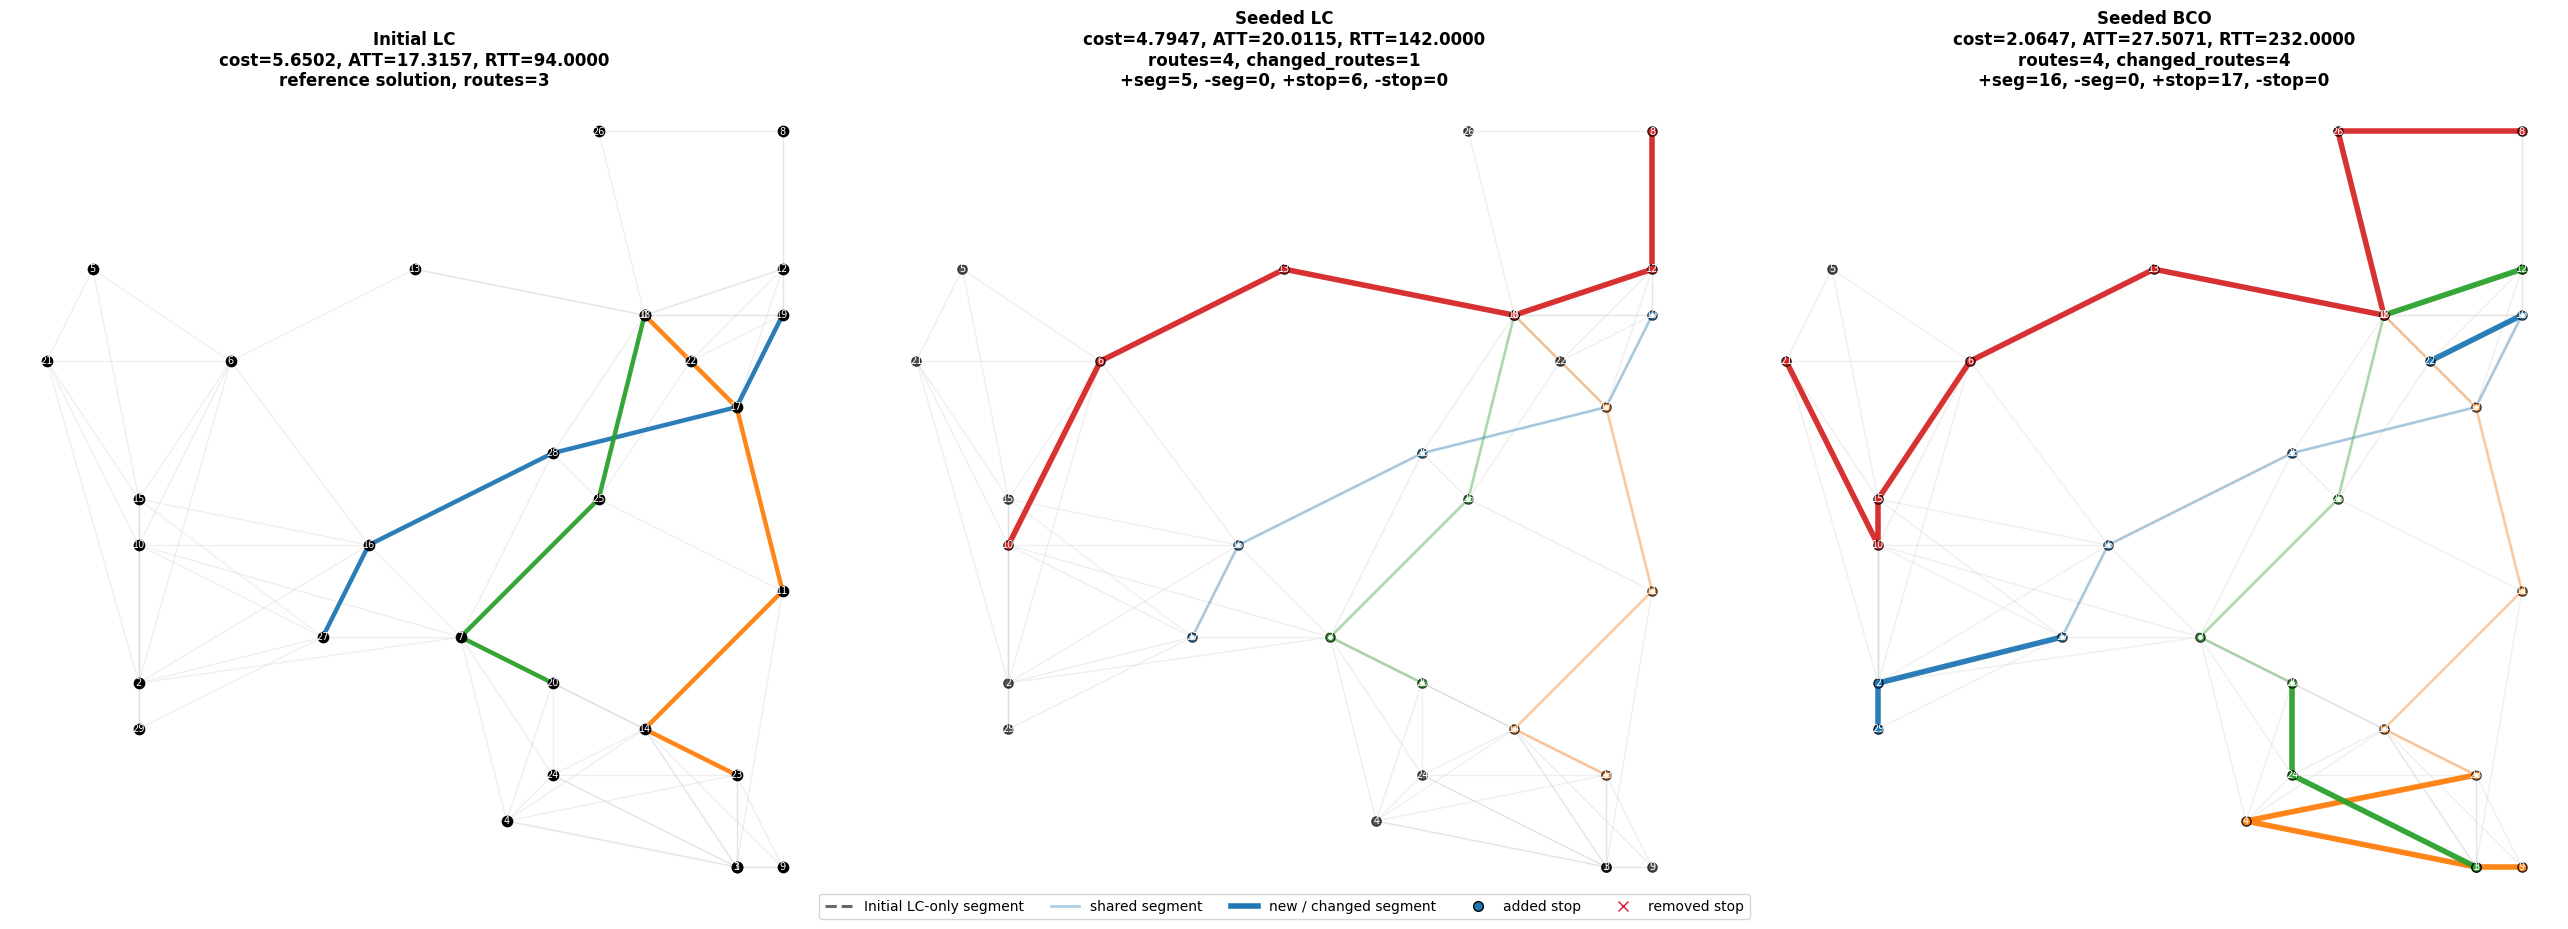

In [55]:

from matplotlib.lines import Line2D


def as_route_tensor(routes):
    if isinstance(routes, torch.Tensor):
        return routes.detach().cpu()
    return get_batch_tensor_from_routes(routes).detach().cpu()


def get_first_route_set(routes):
    routes = as_route_tensor(routes)
    if routes.ndim == 3:
        return routes[0]
    return routes


def route_to_list(route_tensor):
    return [int(x) for x in route_tensor.tolist() if x != -1]


def route_edge_list(route):
    return [(route[i], route[i + 1]) for i in range(len(route) - 1)]


def undirected_edge_key(edge):
    u, v = edge
    return tuple(sorted((u, v)))


def draw_street_graph(ax, coords, street_adj):
    n_nodes = coords.shape[0]
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            if np.isfinite(street_adj[i, j]) or np.isfinite(street_adj[j, i]):
                ax.plot(
                    [coords[i, 0], coords[j, 0]],
                    [coords[i, 1], coords[j, 1]],
                    color="lightgray",
                    linewidth=1.0,
                    alpha=0.35,
                    zorder=1,
                )


def plot_edges(ax, coords, edges, *, color, linewidth, alpha, linestyle="-", zorder=3):
    for u, v in edges:
        ax.plot(
            [coords[u, 0], coords[v, 0]],
            [coords[u, 1], coords[v, 1]],
            color=color,
            linewidth=linewidth,
            alpha=alpha,
            linestyle=linestyle,
            solid_capstyle="round",
            zorder=zorder,
        )


def summarize_route_changes(routes, reference_routes):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    n_routes = max(routes.shape[0], reference_routes.shape[0])
    summary = {
        "changed_routes": 0,
        "added_edges": 0,
        "removed_edges": 0,
        "added_stops": 0,
        "removed_stops": 0,
    }

    for idx in range(n_routes):
        route = route_to_list(routes[idx]) if idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[idx]) if idx < reference_routes.shape[0] else []

        route_edges = {undirected_edge_key(edge) for edge in route_edge_list(route)}
        reference_edges = {undirected_edge_key(edge) for edge in route_edge_list(reference)}
        route_nodes = set(route)
        reference_nodes = set(reference)

        added_edges = route_edges - reference_edges
        removed_edges = reference_edges - route_edges
        added_stops = route_nodes - reference_nodes
        removed_stops = reference_nodes - route_nodes

        if added_edges or removed_edges or added_stops or removed_stops:
            summary["changed_routes"] += 1
        summary["added_edges"] += len(added_edges)
        summary["removed_edges"] += len(removed_edges)
        summary["added_stops"] += len(added_stops)
        summary["removed_stops"] += len(removed_stops)

    return summary


def plot_plain_route_set(ax, routes, coords, street_adj, title, subtitle=None):
    routes = get_first_route_set(routes)
    coords = coords.detach().cpu().numpy() if isinstance(coords, torch.Tensor) else np.asarray(coords)
    street_adj = street_adj.detach().cpu().numpy() if isinstance(street_adj, torch.Tensor) else np.asarray(street_adj)
    draw_street_graph(ax, coords, street_adj)

    colors = plt.cm.tab10(np.linspace(0, 1, max(10, routes.shape[0])))
    for idx, route_tensor in enumerate(routes):
        route = route_to_list(route_tensor)
        if len(route) < 2:
            continue
        color = colors[idx % len(colors)]
        plot_edges(
            ax,
            coords,
            route_edge_list(route),
            color=color,
            linewidth=3.2,
            alpha=0.95,
            zorder=3,
        )

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=55, zorder=5)
    for node_idx, (x, y) in enumerate(coords):
        ax.text(x, y, str(node_idx), fontsize=7, color="white", ha="center", va="center", zorder=6)

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


def plot_route_diff(ax, routes, reference_routes, coords, street_adj, title, subtitle=None):
    routes = get_first_route_set(routes)
    reference_routes = get_first_route_set(reference_routes)
    coords = coords.detach().cpu().numpy() if isinstance(coords, torch.Tensor) else np.asarray(coords)
    street_adj = street_adj.detach().cpu().numpy() if isinstance(street_adj, torch.Tensor) else np.asarray(street_adj)
    draw_street_graph(ax, coords, street_adj)

    colors = plt.cm.tab10(np.linspace(0, 1, max(10, max(routes.shape[0], reference_routes.shape[0]))))
    n_routes = max(routes.shape[0], reference_routes.shape[0])

    for idx in range(n_routes):
        route = route_to_list(routes[idx]) if idx < routes.shape[0] else []
        reference = route_to_list(reference_routes[idx]) if idx < reference_routes.shape[0] else []
        color = colors[idx % len(colors)]

        route_edges_in_order = route_edge_list(route)
        reference_edges_in_order = route_edge_list(reference)
        route_edge_keys = {undirected_edge_key(edge) for edge in route_edges_in_order}
        reference_edge_keys = {undirected_edge_key(edge) for edge in reference_edges_in_order}

        shared_edges = [edge for edge in route_edges_in_order if undirected_edge_key(edge) in reference_edge_keys]
        added_edges = [edge for edge in route_edges_in_order if undirected_edge_key(edge) not in reference_edge_keys]
        removed_edges = [edge for edge in reference_edges_in_order if undirected_edge_key(edge) not in route_edge_keys]

        if removed_edges:
            plot_edges(
                ax,
                coords,
                removed_edges,
                color="dimgray",
                linewidth=2.2,
                alpha=0.85,
                linestyle="--",
                zorder=2,
            )
        if shared_edges:
            plot_edges(
                ax,
                coords,
                shared_edges,
                color=color,
                linewidth=2.0,
                alpha=0.35,
                zorder=3,
            )
        if added_edges:
            plot_edges(
                ax,
                coords,
                added_edges,
                color=color,
                linewidth=4.0,
                alpha=0.95,
                zorder=4,
            )

        route_nodes = set(route)
        reference_nodes = set(reference)
        shared_nodes = sorted(route_nodes & reference_nodes)
        added_nodes = sorted(route_nodes - reference_nodes)
        removed_nodes = sorted(reference_nodes - route_nodes)

        if shared_nodes:
            ax.scatter(coords[shared_nodes, 0], coords[shared_nodes, 1], s=20, facecolors="white", edgecolors=[color], linewidths=1.0, zorder=5)
        if added_nodes:
            ax.scatter(coords[added_nodes, 0], coords[added_nodes, 1], s=40, c=[color], edgecolors="black", linewidths=0.5, zorder=6)
        if removed_nodes:
            ax.scatter(coords[removed_nodes, 0], coords[removed_nodes, 1], s=45, c="crimson", marker="x", linewidths=1.4, zorder=6)

    ax.scatter(coords[:, 0], coords[:, 1], c="black", s=45, alpha=0.65, zorder=4)
    for node_idx, (x, y) in enumerate(coords):
        ax.text(x, y, str(node_idx), fontsize=7, color="white", ha="center", va="center", zorder=7)

    ax.set_title(f"{title}\n{subtitle}" if subtitle else title, fontsize=12, fontweight="bold")
    ax.set_aspect("equal")
    ax.axis("off")


def metric_value(metrics, key):
    value = metrics[key]
    if isinstance(value, torch.Tensor):
        return float(value.squeeze().item())
    return float(value)


coords = input_tensors["node_locs"]
street_adj = input_tensors["street_adj"]
comparison_rows = [
    {
        "label": "Initial LC",
        "routes": lc_base_routes,
        "metrics": lc_base_metrics,
        "is_reference": True,
    },
    {
        "label": "Seeded LC",
        "routes": lc_seeded_routes,
        "metrics": lc_seeded_metrics,
        "is_reference": False,
    },
    {
        "label": "Seeded Neural BCO" if USE_NEURAL_BCO else "Seeded BCO",
        "routes": bco_seeded_routes_tensor,
        "metrics": bco_seeded_metrics,
        "is_reference": False,
    },
]
reference_row = comparison_rows[0]

fig, axes = plt.subplots(1, 3, figsize=(26, 9), constrained_layout=True)
for ax, row in zip(np.ravel(axes), comparison_rows):
    if row["is_reference"]:
        ref_routes = get_first_route_set(row["routes"])
        n_nonempty_routes = int(((ref_routes > -1).sum(dim=-1) > 1).sum().item())
        subtitle = (
            f"cost={metric_value(row['metrics'], 'cost'):.4f}, ATT={metric_value(row['metrics'], 'ATT'):.4f}, RTT={metric_value(row['metrics'], 'RTT'):.4f}"
            f"\nreference solution, routes={n_nonempty_routes}"
        )
        plot_plain_route_set(ax, row["routes"], coords, street_adj, row["label"], subtitle)
        continue

    change_summary = summarize_route_changes(row["routes"], reference_row["routes"])
    compared_routes = get_first_route_set(row["routes"])
    n_nonempty_routes = int(((compared_routes > -1).sum(dim=-1) > 1).sum().item())
    subtitle = (
        f"cost={metric_value(row['metrics'], 'cost'):.4f}, ATT={metric_value(row['metrics'], 'ATT'):.4f}, RTT={metric_value(row['metrics'], 'RTT'):.4f}"
        f"\nroutes={n_nonempty_routes}, changed_routes={change_summary['changed_routes']}"
        f"\n+seg={change_summary['added_edges']}, -seg={change_summary['removed_edges']}, +stop={change_summary['added_stops']}, -stop={change_summary['removed_stops']}"
    )
    plot_route_diff(ax, row["routes"], reference_row["routes"], coords, street_adj, row["label"], subtitle)

style_handles = [
    Line2D([0], [0], color="dimgray", lw=2.2, linestyle="--", label="Initial LC-only segment"),
    Line2D([0], [0], color="tab:blue", lw=2.0, alpha=0.35, label="shared segment"),
    Line2D([0], [0], color="tab:blue", lw=4.0, label="new / changed segment"),
    Line2D([0], [0], marker="o", color="black", markerfacecolor="tab:blue", markersize=7, lw=0, label="added stop"),
    Line2D([0], [0], marker="x", color="crimson", markersize=7, lw=0, label="removed stop"),
]
fig.legend(handles=style_handles, loc="lower center", bbox_to_anchor=(0.5, -0.02), ncol=5, frameon=True)
plt.show()


## 10. Metric Scatter


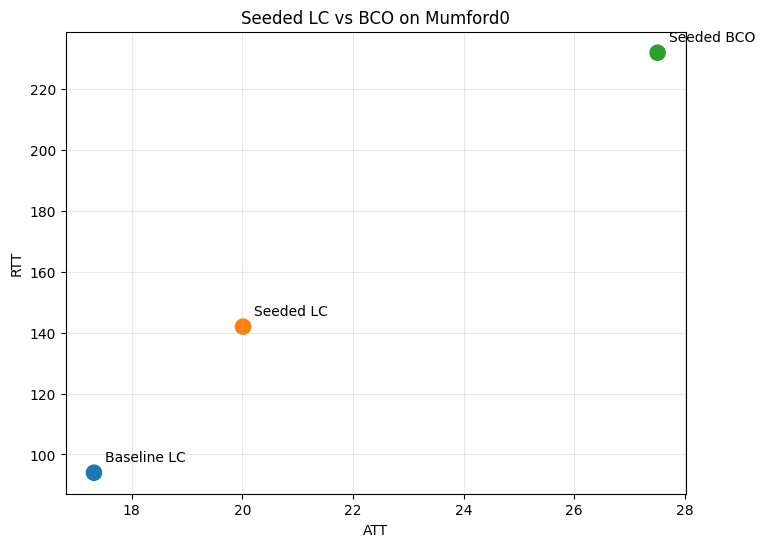

In [56]:
plot_df = comparison_df.copy()
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(plot_df["ATT"], plot_df["RTT"], s=120, color=["tab:blue", "tab:orange", "tab:green"])

for _, row in plot_df.iterrows():
    ax.annotate(row["method"], (row["ATT"], row["RTT"]), xytext=(8, 8), textcoords="offset points")

ax.set_xlabel("ATT")
ax.set_ylabel("RTT")
ax.set_title("Seeded LC vs BCO on Mumford0")
ax.grid(alpha=0.3)
plt.show()
